# Paper Figures 

This notebook implements the updated figures for the ISIT paper
1. **Section A**: Bar plot of σ(L(X;P)) vs detector P
2. **Section B**: Normalized AUC vs |Δ|/σ plot
3. **Section C**: Heatmap for optimal detection (Human vs LLM focus)

All analyses filter to sentences with length in [10, 40] tokens.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, norm, wilcoxon
from sklearn.metrics import roc_auc_score

import importlib
import analysis_utils
importlib.reload(analysis_utils)
from analysis_utils import extract_info_from_path, compute_roc_values

# Global filter: sentences with 10-40 tokens
MIN_LENGTH = 10
MAX_LENGTH = 40

plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

In [19]:
# Dataset paths
wiki_paths = [
    ["../Responses/wiki_Llama3.1_clean_none_Meta-Llama-3.1-8B-Instruct.csv",
     "../Responses/wiki_Falcon_clean_none_Meta-Llama-3.1-8B-Instruct.csv",
     "../Responses/wiki_human_text_none_Meta-Llama-3.1-8B-Instruct.csv",
     "../Responses/wiki_gpt_clean_none_Meta-Llama-3.1-8B-Instruct.csv",
     "../Responses/wiki_R1_clean_none_Meta-Llama-3.1-8B-Instruct.csv"],
    ["../Responses/wiki_Llama3.1_clean_none_falcon-7b.csv",
     "../Responses/wiki_Falcon_clean_none_falcon-7b.csv",
     "../Responses/wiki_human_text_none_falcon-7b.csv",
     "../Responses/wiki_gpt_clean_none_falcon-7b.csv",
     "../Responses/wiki_R1_clean_none_falcon-7b.csv"],
    ["../Responses/wiki_Llama3.1_clean_none_phi-2.csv",
     "../Responses/wiki_Falcon_clean_none_phi-2.csv",
     "../Responses/wiki_human_text_none_phi-2.csv",
     "../Responses/wiki_gpt_clean_none_phi-2.csv",
     "../Responses/wiki_R1_clean_none_phi-2.csv"],
    ["../Responses/wiki_Llama3.1_clean_none_DeepSeek-R1-Distill-Qwen-7B.csv",
     "../Responses/wiki_Falcon_clean_none_DeepSeek-R1-Distill-Qwen-7B.csv",
     "../Responses/wiki_human_text_none_DeepSeek-R1-Distill-Qwen-7B.csv",
     "../Responses/wiki_gpt_clean_none_DeepSeek-R1-Distill-Qwen-7B.csv",
     "../Responses/wiki_R1_clean_none_DeepSeek-R1-Distill-Qwen-7B.csv"]
]

news_paths = [
    ["../Responses/news_Llama3.1_clean_none_Meta-Llama-3.1-8B-Instruct.csv",
     "../Responses/news_Falcon_clean_none_Meta-Llama-3.1-8B-Instruct.csv",
     "../Responses/news_human_text_none_Meta-Llama-3.1-8B-Instruct.csv",
     "../Responses/news_gpt_clean_none_Meta-Llama-3.1-8B-Instruct.csv",
     "../Responses/news_R1_clean_none_Meta-Llama-3.1-8B-Instruct.csv"],
    ["../Responses/news_Llama3.1_clean_none_falcon-7b.csv",
     "../Responses/news_Falcon_clean_none_falcon-7b.csv",
     "../Responses/news_human_text_none_falcon-7b.csv",
     "../Responses/news_gpt_clean_none_falcon-7b.csv",
     "../Responses/news_R1_clean_none_falcon-7b.csv"],
    ["../Responses/news_Llama3.1_clean_none_phi-2.csv",
     "../Responses/news_Falcon_clean_none_phi-2.csv",
     "../Responses/news_human_text_none_phi-2.csv",
     "../Responses/news_gpt_clean_none_phi-2.csv",
     "../Responses/news_R1_clean_none_phi-2.csv"],
    ["../Responses/news_Llama3.1_clean_none_DeepSeek-R1-Distill-Qwen-7B.csv",
     "../Responses/news_Falcon_clean_none_DeepSeek-R1-Distill-Qwen-7B.csv",
     "../Responses/news_human_text_none_DeepSeek-R1-Distill-Qwen-7B.csv",
     "../Responses/news_gpt_clean_none_DeepSeek-R1-Distill-Qwen-7B.csv",
     "../Responses/news_R1_clean_none_DeepSeek-R1-Distill-Qwen-7B.csv"]
]

abstracts_paths = [
    ["../Responses/abstracts_Llama3.1_clean_none_Meta-Llama-3.1-8B-Instruct.csv",
     "../Responses/abstracts_Falcon_clean_none_Meta-Llama-3.1-8B-Instruct.csv",
     "../Responses/abstracts_human_text_none_Meta-Llama-3.1-8B-Instruct.csv",
     "../Responses/abstracts_gpt_clean_none_Meta-Llama-3.1-8B-Instruct.csv",
     "../Responses/abstracts_R1_clean_none_Meta-Llama-3.1-8B-Instruct.csv"],
    ["../Responses/abstracts_Llama3.1_clean_none_falcon-7b.csv",
     "../Responses/abstracts_Falcon_clean_none_falcon-7b.csv",
     "../Responses/abstracts_human_text_none_falcon-7b.csv",
     "../Responses/abstracts_gpt_clean_none_falcon-7b.csv",
     "../Responses/abstracts_R1_clean_none_falcon-7b.csv"],
    ["../Responses/abstracts_Llama3.1_clean_none_phi-2.csv",
     "../Responses/abstracts_Falcon_clean_none_phi-2.csv",
     "../Responses/abstracts_human_text_none_phi-2.csv",
     "../Responses/abstracts_gpt_clean_none_phi-2.csv",
     "../Responses/abstracts_R1_clean_none_phi-2.csv"],
    ["../Responses/abstracts_Llama3.1_clean_none_DeepSeek-R1-Distill-Qwen-7B.csv",
     "../Responses/abstracts_Falcon_clean_none_DeepSeek-R1-Distill-Qwen-7B.csv",
     "../Responses/abstracts_human_text_none_DeepSeek-R1-Distill-Qwen-7B.csv",
     "../Responses/abstracts_gpt_clean_none_DeepSeek-R1-Distill-Qwen-7B.csv",
     "../Responses/abstracts_R1_clean_none_DeepSeek-R1-Distill-Qwen-7B.csv"]
]

# Constants
DETECTOR_NAMES = ['Llama-3.1-8B', 'Falcon-7B', 'Phi-2', 'DeepSeek-R1']
AUTHOR_NAMES = ['Llama3.1', 'Falcon', 'Human', 'GPT', 'R1']
DATASET_NAMES = ['Wiki', 'News', 'Abstracts']

In [20]:
# =============================================================================
# Dataset Statistics (after filtering to 10-40 words)
# =============================================================================

def get_dataset_stats(paths, dataset_name):
    """Get sentence counts per author for a dataset, after filtering."""
    # Use first detector's paths (counts are same across detectors)
    lm_paths = paths[0]
    author_names = ['Llama3.1', 'Falcon', 'Human', 'GPT', 'R1']
    
    stats = {'Dataset': dataset_name}
    total = 0
    
    for i, (path, author) in enumerate(zip(lm_paths, author_names)):
        df = pd.read_csv(path)
        # Filter to 10-40 words
        filtered = df[(df['length'] >= MIN_LENGTH) & (df['length'] <= MAX_LENGTH)]
        stats[author] = len(filtered)
        total += len(filtered)
    
    stats['Total'] = total
    # Approximate articles (sentences / ~avg sentences per article)
    # Each dataset has ~1500 documents
    return stats

# Compute stats for each dataset
wiki_stats = get_dataset_stats(wiki_paths, 'Wiki')
news_stats = get_dataset_stats(news_paths, 'News')
abstracts_stats = get_dataset_stats(abstracts_paths, 'Abstracts')

# Create summary DataFrame
stats_df = pd.DataFrame([wiki_stats, news_stats, abstracts_stats])

print("=" * 80)
print(f"Dataset Statistics (sentences with {MIN_LENGTH}–{MAX_LENGTH} words)")
print("=" * 80)
print()
print(stats_df.to_string(index=False))

# Totals
print()
print("-" * 80)
print("Totals across all datasets:")
print("-" * 80)
for col in ['Llama3.1', 'Falcon', 'Human', 'GPT', 'R1', 'Total']:
    print(f"  {col:10}: {stats_df[col].sum():,} sentences")

# Per author average
print()
print("-" * 80)
print("Average sentences per author per dataset:")
print("-" * 80)
avg_per_author = stats_df['Total'].sum() / 5 / 3
print(f"  ~{avg_per_author:,.0f} sentences per author per dataset")

# Document counts (from source files)
print()
print("-" * 80)
print("Document counts (from source datasets):")
print("-" * 80)
try:
    wiki_src = pd.read_csv('../src/wiki_dataset_clean.csv')
    news_src = pd.read_csv('../src/news_dataset_clean.csv')
    abstracts_src = pd.read_csv('../src/abstracts_dataset_clean.csv')
    print(f"  Wiki:      {len(wiki_src):,} articles")
    print(f"  News:      {len(news_src):,} articles")
    print(f"  Abstracts: {len(abstracts_src):,} abstracts")
    print(f"  Total:     {len(wiki_src) + len(news_src) + len(abstracts_src):,} documents")
except Exception as e:
    print(f"  (Could not load source files: {e})")

Dataset Statistics (sentences with 10–40 words)

  Dataset  Llama3.1  Falcon  Human   GPT    R1  Total
     Wiki     15400   10609  11590 15849 11075  64523
     News     36556   16519  26270 27133 27500 133978
Abstracts     22927    8319  14210 18729 11926  76111

--------------------------------------------------------------------------------
Totals across all datasets:
--------------------------------------------------------------------------------
  Llama3.1  : 74,883 sentences
  Falcon    : 35,447 sentences
  Human     : 52,070 sentences
  GPT       : 61,711 sentences
  R1        : 50,501 sentences
  Total     : 274,612 sentences

--------------------------------------------------------------------------------
Average sentences per author per dataset:
--------------------------------------------------------------------------------
  ~18,307 sentences per author per dataset

--------------------------------------------------------------------------------
Document counts (from sourc

---
## Section A: Variance Independence - σ vs Detector P

Bar plot showing σ(L(X;P)) vs detector P. Different colors for datasets.
Goal: Show σ doesn't depend strongly on P.

In [21]:
# Compute σ by detector AND sentence length bin
LENGTH_BINS_A = [(10, 20), (20, 30), (30, 40)]
BIN_LABELS_A = ['10-20', '20-30', '30-40']

def compute_sigma_by_detector_and_length(all_paths_dict):
    """Compute σ(L(X;P)) for each (detector, length bin) combination."""
    results = []
    
    for dataset_name, dataset_paths in all_paths_dict.items():
        for det_idx, lm_paths in enumerate(dataset_paths):
            detector = DETECTOR_NAMES[det_idx]
            
            for bin_idx, (low, high) in enumerate(LENGTH_BINS_A):
                all_responses = []
                for path in lm_paths:
                    df = pd.read_csv(path)
                    mask = (df['length'] >= low) & (df['length'] < high)
                    responses = df.loc[mask, 'response'].dropna().values
                    all_responses.extend(responses)
                
                all_responses = np.array(all_responses)
                sigma = np.std(all_responses) if len(all_responses) > 0 else np.nan
                
                results.append({
                    'dataset': dataset_name,
                    'detector': detector,
                    'length_bin': BIN_LABELS_A[bin_idx],
                    'sigma': sigma,
                    'n_samples': len(all_responses)
                })
    
    return pd.DataFrame(results)

all_paths = {'Wiki': wiki_paths, 'News': news_paths, 'Abstracts': abstracts_paths}
sigma_df = compute_sigma_by_detector_and_length(all_paths)
print(sigma_df.to_string(index=False))

  dataset     detector length_bin    sigma  n_samples
     Wiki Llama-3.1-8B      10-20 0.705004      33237
     Wiki Llama-3.1-8B      20-30 0.603110      25734
     Wiki Llama-3.1-8B      30-40 0.670588       5407
     Wiki    Falcon-7B      10-20 0.693623      33237
     Wiki    Falcon-7B      20-30 0.592144      25734
     Wiki    Falcon-7B      30-40 0.639828       5407
     Wiki        Phi-2      10-20 0.708274      33223
     Wiki        Phi-2      20-30 0.597073      25739
     Wiki        Phi-2      30-40 0.657481       5405
     Wiki  DeepSeek-R1      10-20 1.094995      33233
     Wiki  DeepSeek-R1      20-30 0.881065      25734
     Wiki  DeepSeek-R1      30-40 0.953432       5407
     News Llama-3.1-8B      10-20 0.824802      55549
     News Llama-3.1-8B      20-30 0.635809      61998
     News Llama-3.1-8B      30-40 0.618381      16026
     News    Falcon-7B      10-20 0.732230      55549
     News    Falcon-7B      20-30 0.568886      61998
     News    Falcon-7B      

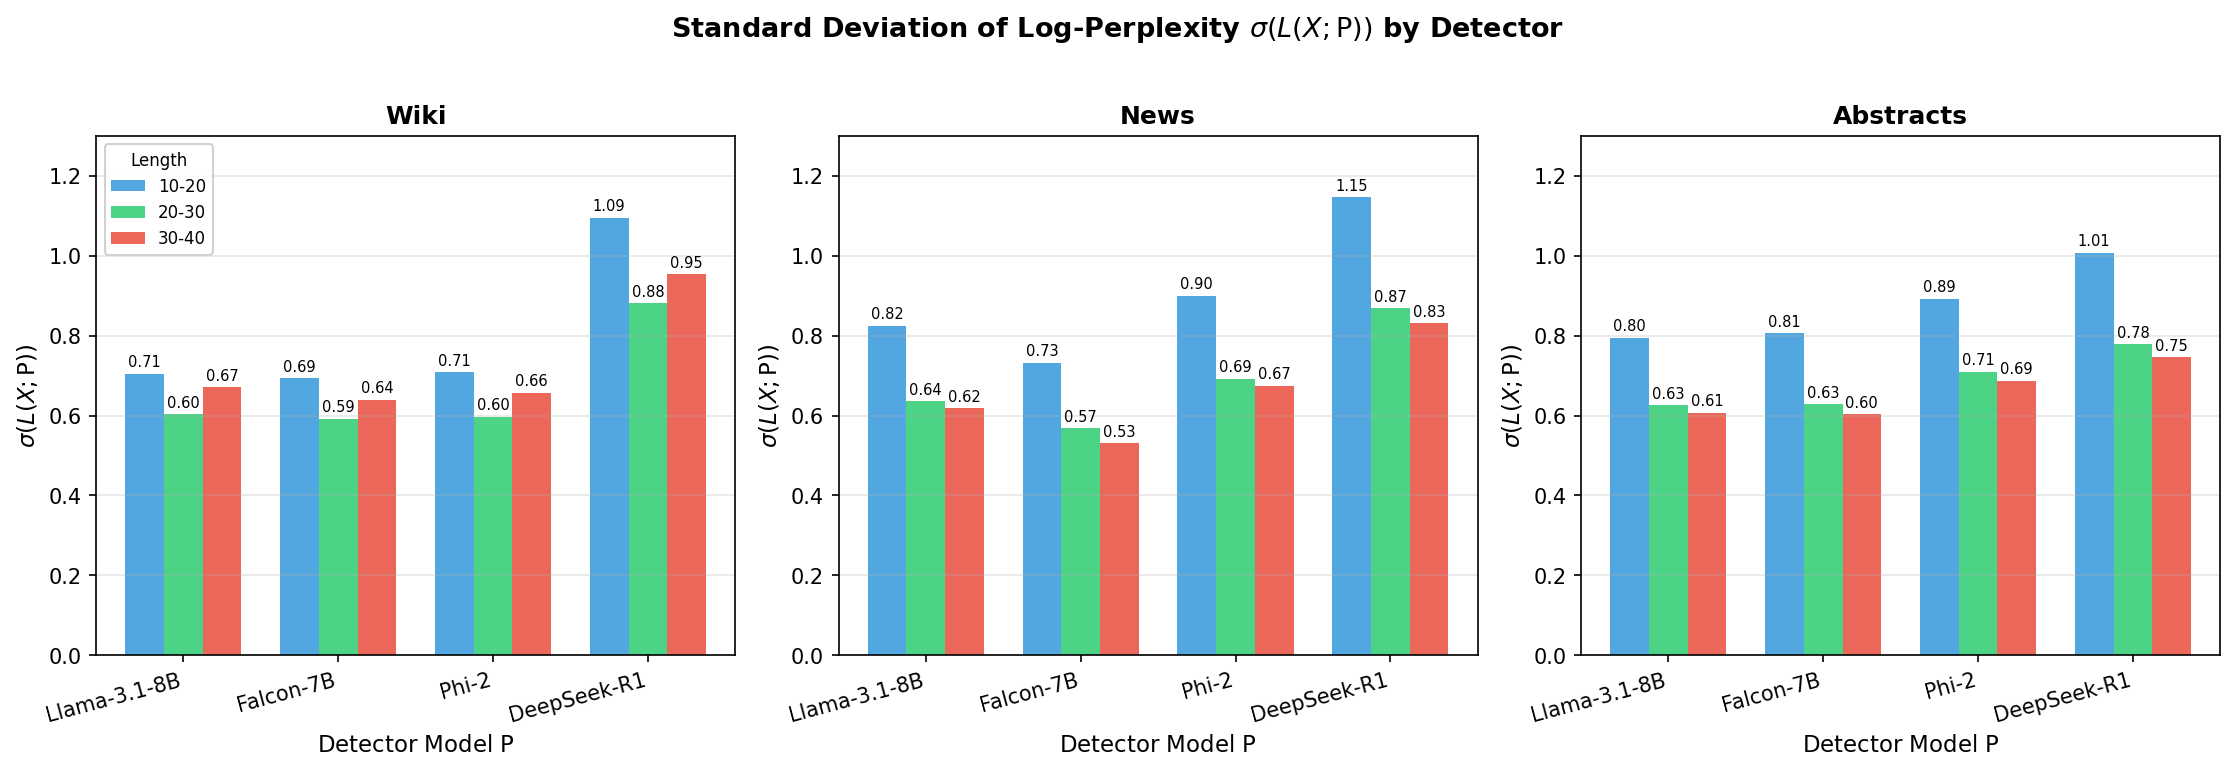


Max/min σ ratio across detectors (by dataset):
  Wiki: 1.85
  News: 2.16
  Abstracts: 1.67


In [22]:
def plot_sigma_bar_chart(sigma_data, detectors=None, save_path=None, 
                         title_suffix='', ylim=1.3, trimmed=False):
    """
    Plot 3-panel bar chart of σ vs detector, split by domain, colored by length bin.
    
    Args:
        sigma_data: DataFrame with columns ['dataset', 'detector', 'length_bin', 'sigma']
        detectors: List of detectors to include (default: all DETECTOR_NAMES)
        save_path: Path to save figure (optional)
        title_suffix: Suffix to add to title (e.g., ' (excl. DeepSeek)')
        ylim: Y-axis upper limit
        trimmed: If True, use trimmed σ label
    """
    if detectors is None:
        detectors = DETECTOR_NAMES
    
    # Filter data to selected detectors
    plot_data = sigma_data[sigma_data['detector'].isin(detectors)]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    x = np.arange(len(detectors))
    width = 0.25
    length_colors = {'10-20': '#3498db', '20-30': '#2ecc71', '30-40': '#e74c3c'}
    
    for ax, dataset in zip(axes, DATASET_NAMES):
        subset = plot_data[plot_data['dataset'] == dataset]
        
        for i, length_bin in enumerate(BIN_LABELS_A):
            bin_data = subset[subset['length_bin'] == length_bin]
            sigmas = [bin_data[bin_data['detector'] == d]['sigma'].values[0] for d in detectors]
            ax.bar(x + i * width, sigmas, width, label=length_bin, 
                   color=length_colors[length_bin], alpha=0.85)
            
            for j, sigma in enumerate(sigmas):
                ax.text(x[j] + i * width, sigma + 0.01, f'{sigma:.2f}', 
                       ha='center', va='bottom', fontsize=7)
        
        ax.set_xlabel(r'Detector Model $\mathrm{P}$', fontsize=11)
        ylabel = r'$\sigma_{\mathrm{trimmed}}(L(X; \mathrm{P}))$' if trimmed else r'$\sigma(L(X; \mathrm{P}))$'
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(f'{dataset}', fontsize=12, fontweight='bold')
        ax.set_xticks(x + width)
        ax.set_xticklabels(detectors, rotation=15, ha='right', fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_ylim(0, ylim)
    
    # Legend inside top-left of first (Wiki) plot - saves vertical space
    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles, labels, loc='upper left', fontsize=8, frameon=True,
                   title='Length', title_fontsize=8, framealpha=0.9)
    
    title = r'Standard Deviation of Log-Perplexity $\sigma(L(X; \mathrm{P}))$ by Detector' + title_suffix
    plt.suptitle(title, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    # Summary stats
    print(f"\nMax/min σ ratio across detectors (by dataset){title_suffix}:")
    for dataset in DATASET_NAMES:
        subset = plot_data[plot_data['dataset'] == dataset]
        ratio = subset['sigma'].max() / subset['sigma'].min()
        print(f"  {dataset}: {ratio:.2f}")

# Plot with all 4 detectors
plot_sigma_bar_chart(sigma_df, save_path='../images/sigma_vs_detector_all.png')

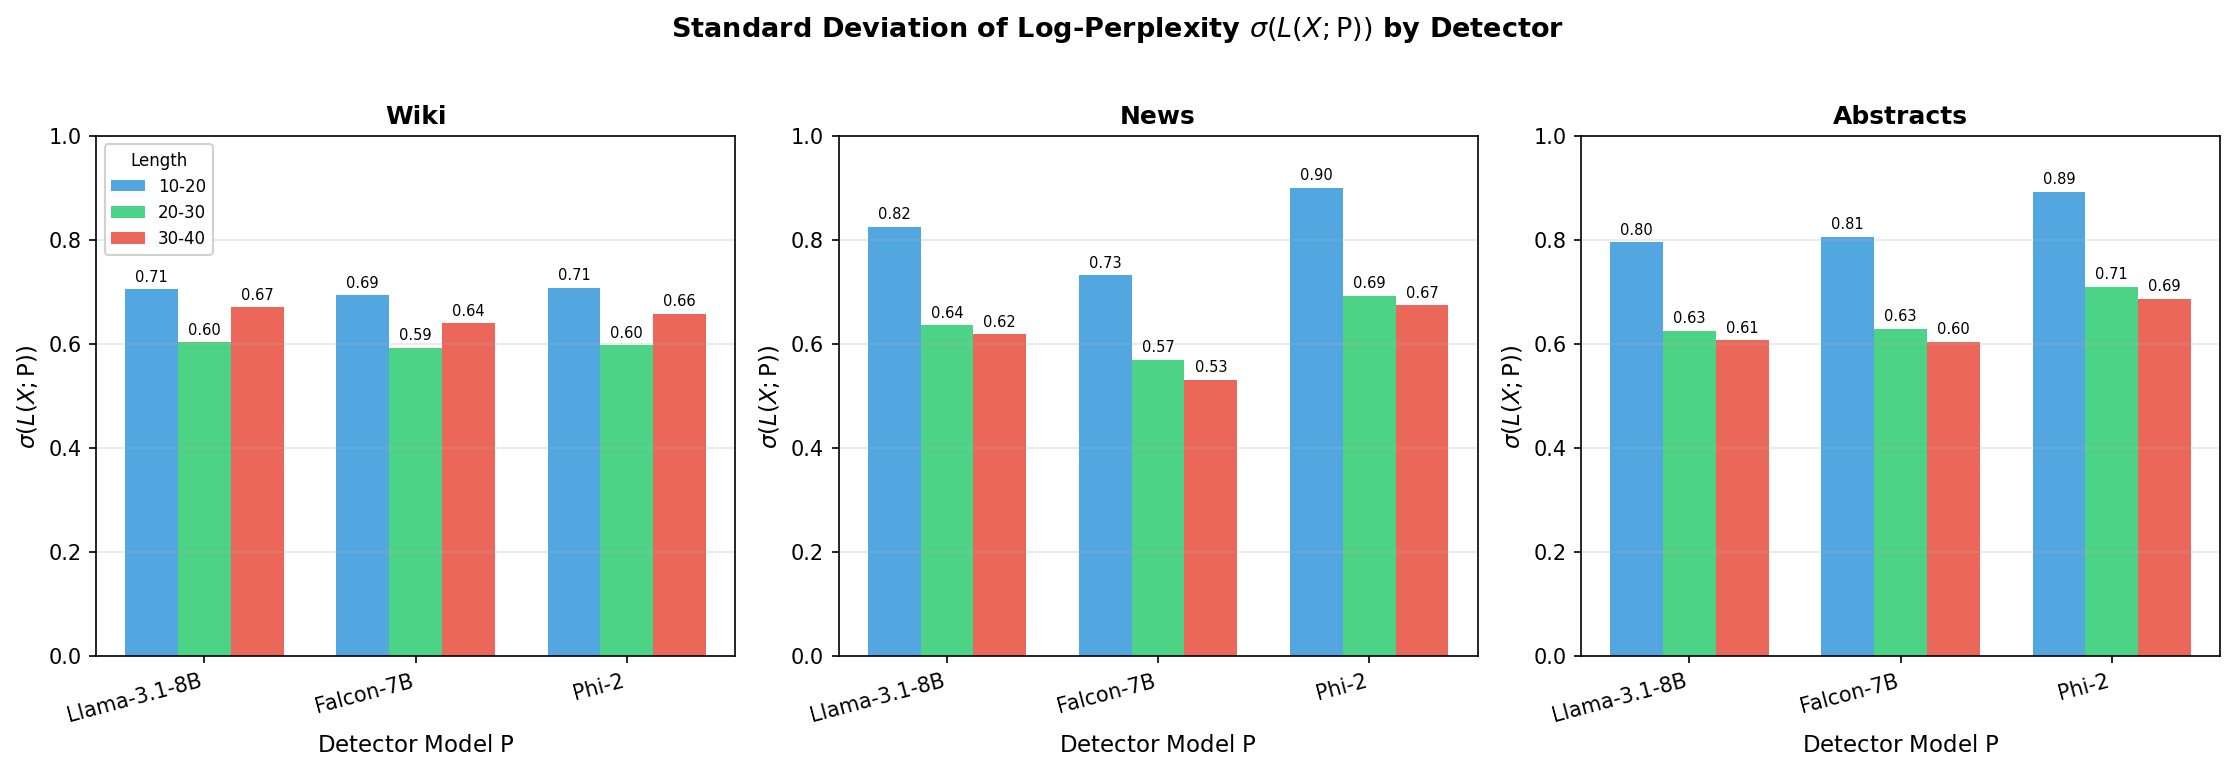


Max/min σ ratio across detectors (by dataset):
  Wiki: 1.20
  News: 1.69
  Abstracts: 1.48


In [23]:
# Plot without DeepSeek-R1 (outlier with higher variance, likely due to chat template with role/<think> tokens)
DETECTORS_NO_R1 = ['Llama-3.1-8B', 'Falcon-7B', 'Phi-2']

plot_sigma_bar_chart(
    sigma_df, 
    detectors=DETECTORS_NO_R1,
    save_path='../images/sigma_vs_detector.png',
    title_suffix='',
    ylim=1.0  
)

---
## Section B: Normalized AUC vs |Δ|/σ

Normalize each comparison by its pooled σ so points cluster around the Gaussian reference curve.
Theoretical: AUC = Φ(|Δ|/(σ√2)), so when plotting vs |Δ|/σ, the curve is AUC = Φ(x/√2).

In [24]:
# Length bins (filtered to [10, 40])
LENGTH_BINS = [(10, 15), (15, 20), (20, 25), (25, 30), (30, 35), (35, 40)]
BIN_LABELS = ['10-15', '15-20', '20-25', '25-30', '30-35', '35-40']
MIN_SAMPLES = 30

def compute_normalized_auc_vs_delta(dataset_paths, dataset_name):
    """Compute |Δ|/σ (normalized delta) and AUC for each comparison."""
    results = []
    
    for det_idx, lm_paths in enumerate(dataset_paths):
        detector = DETECTOR_NAMES[det_idx]
        
        for i, auth1_path in enumerate(lm_paths):
            for j, auth2_path in enumerate(lm_paths):
                if i >= j:
                    continue
                
                auth1_df = pd.read_csv(auth1_path)
                auth2_df = pd.read_csv(auth2_path)
                
                _, auth1_name, _, _ = extract_info_from_path(auth1_path)
                _, auth2_name, _, _ = extract_info_from_path(auth2_path)
                
                for bin_idx, (low, high) in enumerate(LENGTH_BINS):
                    mask1 = (auth1_df['length'] >= low) & (auth1_df['length'] < high)
                    mask2 = (auth2_df['length'] >= low) & (auth2_df['length'] < high)
                    
                    subset1 = auth1_df.loc[mask1, 'response'].dropna()
                    subset2 = auth2_df.loc[mask2, 'response'].dropna()
                    
                    if len(subset1) < MIN_SAMPLES or len(subset2) < MIN_SAMPLES:
                        continue
                    
                    mu_0, mu_1 = subset1.mean(), subset2.mean()
                    delta = abs(mu_1 - mu_0)
                    
                    # Pooled standard deviation
                    n0, n1 = len(subset1), len(subset2)
                    var0, var1 = subset1.var(), subset2.var()
                    pooled_var = ((n0 - 1) * var0 + (n1 - 1) * var1) / (n0 + n1 - 2)
                    pooled_std = np.sqrt(pooled_var)
                    
                    delta_normalized = delta / pooled_std if pooled_std > 0 else 0
                    
                    # Compute AUC
                    y_true = np.concatenate([np.zeros(n0), np.ones(n1)])
                    y_score = np.concatenate([subset1.values, subset2.values])
                    auc = roc_auc_score(y_true, y_score)
                    if auc < 0.5:
                        auc = 1 - auc
                    
                    results.append({
                        'delta': delta,
                        'delta_normalized': delta_normalized,
                        'pooled_std': pooled_std,
                        'auc': auc,
                        'length_bin': BIN_LABELS[bin_idx],
                        'dataset': dataset_name,
                        'detector': detector
                    })
    
    return pd.DataFrame(results)

# Compute for all datasets
wiki_results = compute_normalized_auc_vs_delta(wiki_paths, 'Wiki')
news_results = compute_normalized_auc_vs_delta(news_paths, 'News')
abstracts_results = compute_normalized_auc_vs_delta(abstracts_paths, 'Abstracts')

all_results = pd.concat([wiki_results, news_results, abstracts_results], ignore_index=True)
print(f"Total data points: {len(all_results)}")
print(f"By dataset: {all_results.groupby('dataset').size().to_dict()}")

Total data points: 720
By dataset: {'Abstracts': 240, 'News': 240, 'Wiki': 240}


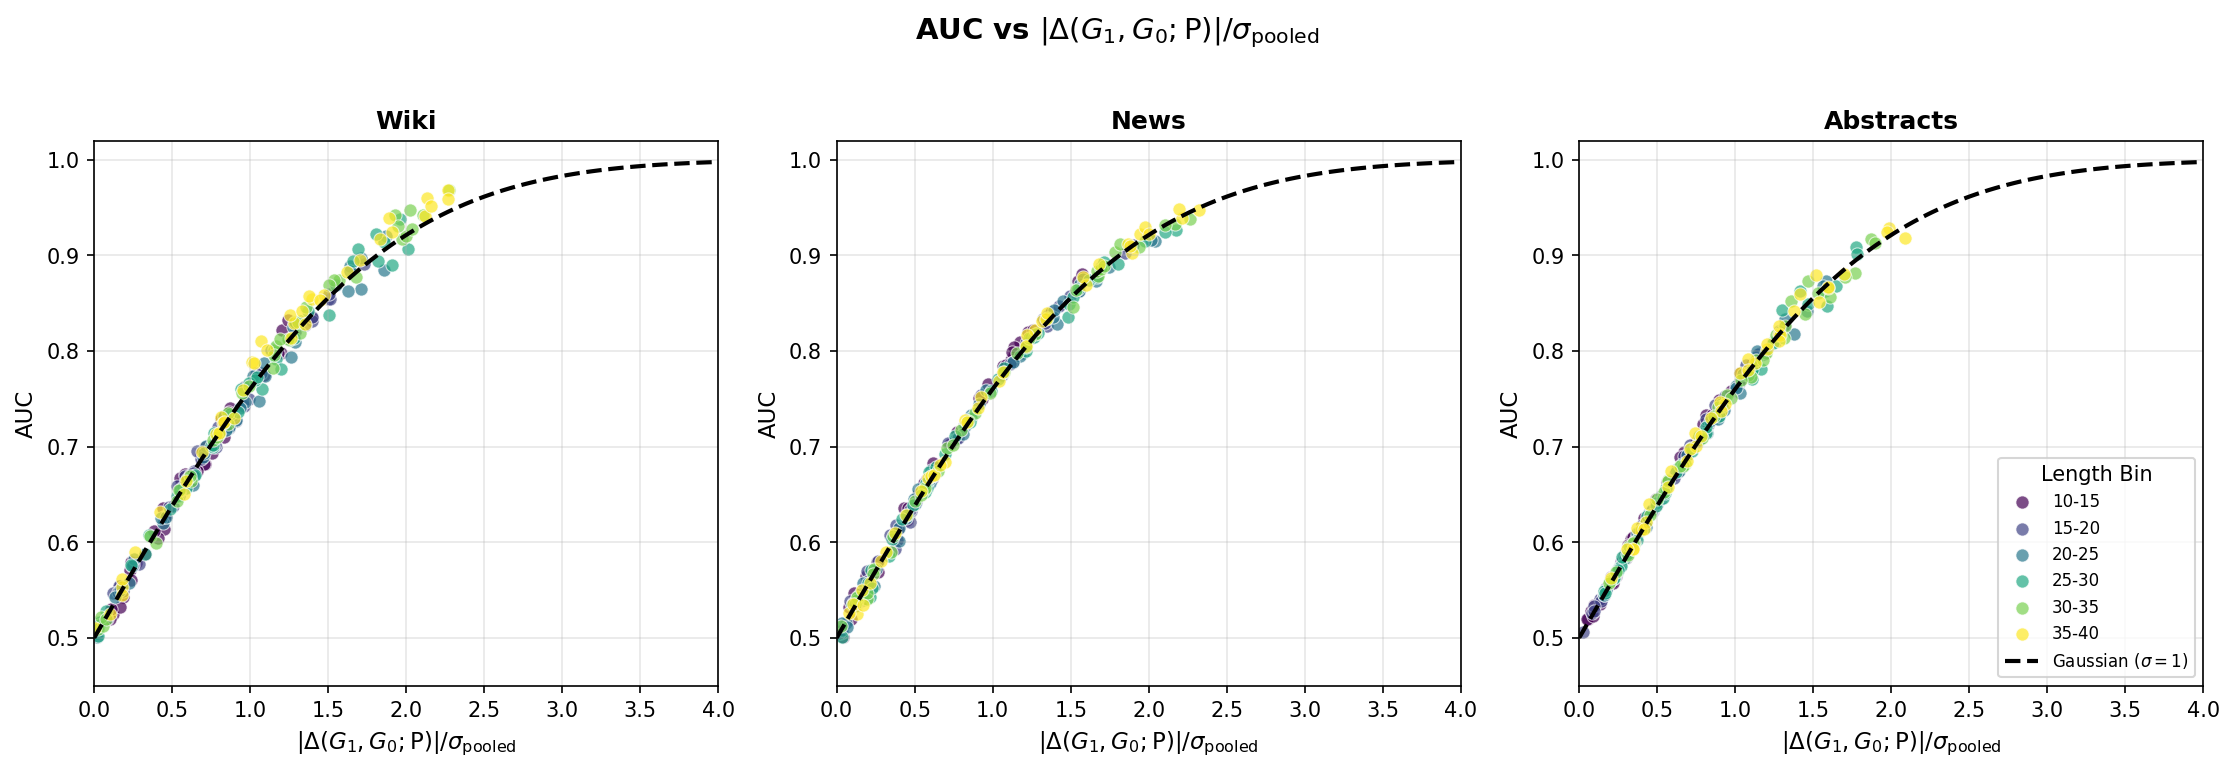


Global Pearson correlation: r = 0.99


In [25]:
# Theoretical Gaussian AUC: AUC = Φ(|Δ|/σ / √2)
# When x = |Δ|/σ_pooled, the curve becomes AUC = Φ(x/√2) which is equivalent to σ=1
def gaussian_auc_normalized(delta_over_sigma):
    return norm.cdf(delta_over_sigma / np.sqrt(2))

# 3-Panel plot: Normalized AUC vs |Δ|/σ_pooled by dataset
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cmap = plt.cm.viridis
n_bins = len(BIN_LABELS)
bin_colors = {label: cmap(i / (n_bins - 1)) for i, label in enumerate(BIN_LABELS)}

x_theory = np.linspace(0, 4, 100)
y_theory = gaussian_auc_normalized(x_theory)

for ax, dataset in zip(axes, DATASET_NAMES):
    subset = all_results[all_results['dataset'] == dataset]
    
    for length_bin in BIN_LABELS:
        bin_data = subset[subset['length_bin'] == length_bin]
        if len(bin_data) > 0:
            ax.scatter(bin_data['delta_normalized'], bin_data['auc'],
                      c=[bin_colors[length_bin]], label=length_bin,
                      alpha=0.7, s=40, edgecolors='white', linewidth=0.5)
    
    # Theoretical curve with σ=1 label
    ax.plot(x_theory, y_theory, 'k--', linewidth=2, label=r'Gaussian ($\sigma=1$)')
    
    ax.set_xlabel(r'$|\Delta(G_1, G_0; \mathrm{P})| / \sigma_{\mathrm{pooled}}$', fontsize=11)
    ax.set_ylabel('AUC', fontsize=11)
    ax.set_title(f'{dataset}', fontsize=12, fontweight='bold')
    ax.set_xlim(0, 4)
    ax.set_ylim(0.45, 1.02)
    ax.grid(True, alpha=0.3)

handles, labels = axes[-1].get_legend_handles_labels()
axes[-1].legend(handles, labels, loc='lower right', fontsize=8, title='Length Bin')

plt.suptitle(r'AUC vs $|\Delta(G_1, G_0; \mathrm{P})| / \sigma_{\mathrm{pooled}}$', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/auc_vs_delta_normalized.png', dpi=300, bbox_inches='tight')
plt.show()

# Report correlation
global_corr, _ = pearsonr(all_results['delta_normalized'], all_results['auc'])
print(f"\nGlobal Pearson correlation: r = {global_corr:.2f}")

---
## Section C: Optimal Detection Heatmap (Human vs LLM Focus)

Create heatmap showing AUC for each (Author pair, Detector P) combination.
Focus on pairs including Human author to address Theorem 4 (composite alternative).

In [26]:
def compute_auc_matrix(dataset_paths, dataset_name, human_pairs_only=True):
    """Compute AUC matrix: rows = author pairs, columns = detectors."""
    results = []
    
    for det_idx, lm_paths in enumerate(dataset_paths):
        detector = DETECTOR_NAMES[det_idx]
        
        for i, auth1_path in enumerate(lm_paths):
            for j, auth2_path in enumerate(lm_paths):
                if i >= j:
                    continue
                
                _, auth1_name, _, _ = extract_info_from_path(auth1_path)
                _, auth2_name, _, _ = extract_info_from_path(auth2_path)
                
                auth1_short = auth1_name.split()[0]
                auth2_short = auth2_name.split()[0]
                
                if human_pairs_only:
                    if 'Human' not in auth1_short and 'Human' not in auth2_short:
                        continue
                
                auth1_df = pd.read_csv(auth1_path)
                auth2_df = pd.read_csv(auth2_path)
                
                mask1 = (auth1_df['length'] >= MIN_LENGTH) & (auth1_df['length'] <= MAX_LENGTH)
                mask2 = (auth2_df['length'] >= MIN_LENGTH) & (auth2_df['length'] <= MAX_LENGTH)
                
                subset1 = auth1_df.loc[mask1, 'response'].dropna()
                subset2 = auth2_df.loc[mask2, 'response'].dropna()
                
                if len(subset1) < 30 or len(subset2) < 30:
                    continue
                
                y_true = np.concatenate([np.zeros(len(subset1)), np.ones(len(subset2))])
                y_score = np.concatenate([subset1.values, subset2.values])
                auc = roc_auc_score(y_true, y_score)
                if auc < 0.5:
                    auc = 1 - auc
                
                # Check if self-detection (detector matches LLM author)
                detector_to_author = {'Llama-3.1-8B': 'Llama3.1', 'Falcon-7B': 'Falcon', 'DeepSeek-R1': 'R1'}
                det_author = detector_to_author.get(detector, None)
                is_self = det_author in [auth1_short, auth2_short]
                
                # For Human pairs, identify the LLM author
                llm_author = auth1_short if auth2_short == 'Human' else auth2_short
                pair_name = f"{llm_author}"  # Just the LLM name for cleaner display
                
                results.append({
                    'dataset': dataset_name,
                    'pair': pair_name,
                    'llm_author': llm_author,
                    'detector': detector,
                    'auc': auc,
                    'is_self': is_self
                })
    
    return pd.DataFrame(results)

# Compute AUC matrix for Human pairs
wiki_auc = compute_auc_matrix(wiki_paths, 'Wiki', human_pairs_only=True)
news_auc = compute_auc_matrix(news_paths, 'News', human_pairs_only=True)
abstracts_auc = compute_auc_matrix(abstracts_paths, 'Abstracts', human_pairs_only=True)

all_auc = pd.concat([wiki_auc, news_auc, abstracts_auc], ignore_index=True)
print(f"Total comparisons (Human pairs only): {len(all_auc)}")
print(f"\nUnique pairs: {all_auc['pair'].unique()}")

Total comparisons (Human pairs only): 48

Unique pairs: ['Llama3.1' 'Falcon' 'Gpt' 'R1']


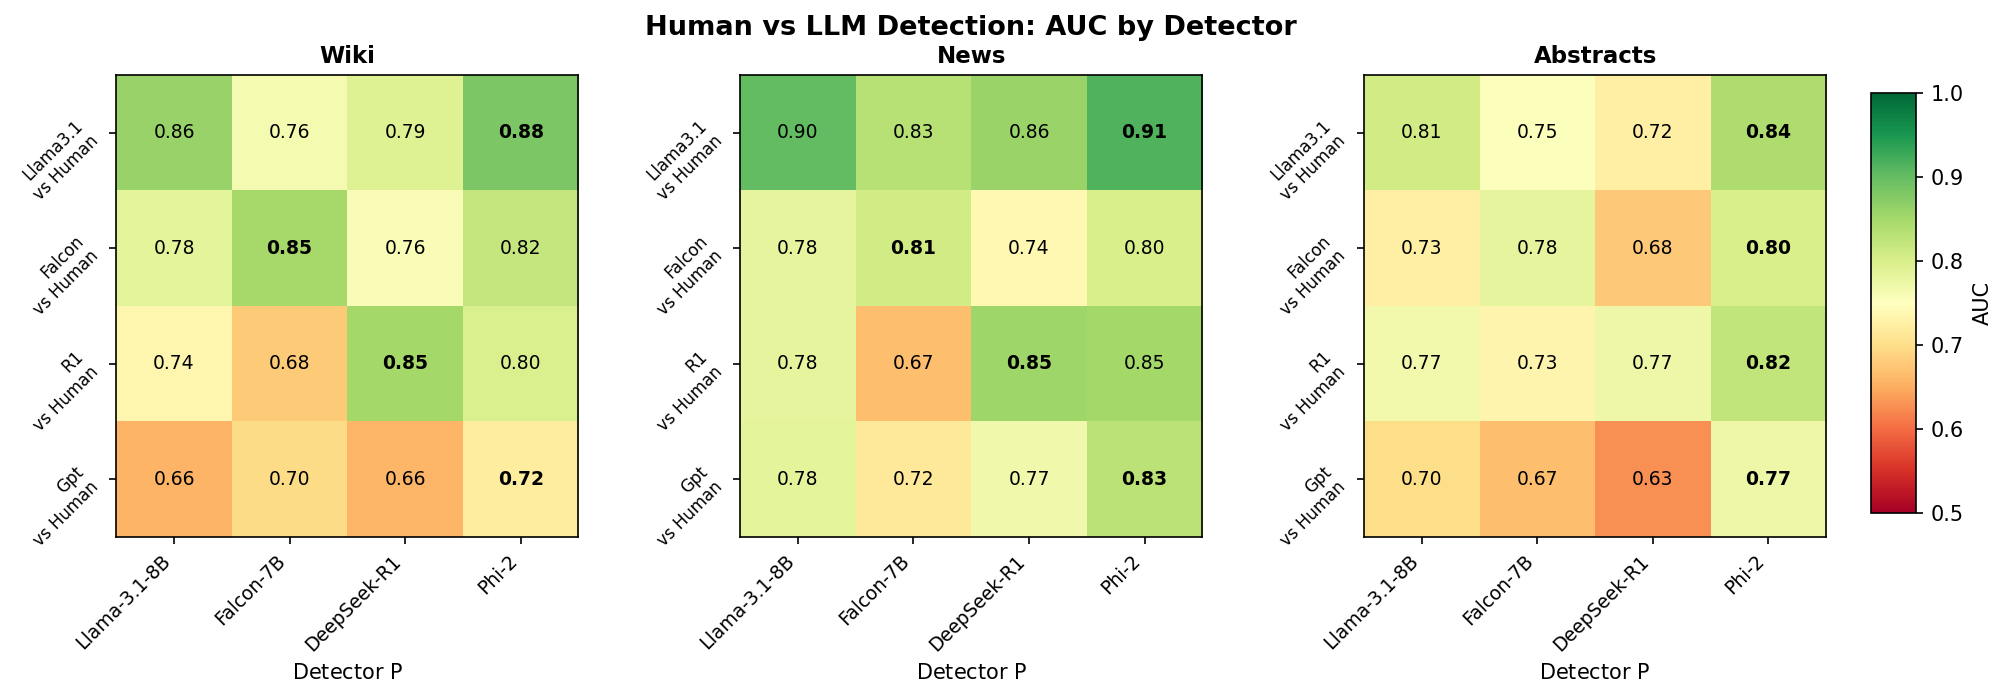

In [27]:
# Create heatmap: Rows = LLM authors (Human-X pairs), Columns = Detectors
# Ordered to create diagonal: Llama, Falcon, R1, GPT (matching detector order)

# Desired order for columns (detectors) and rows (LLM authors) to align diagonal
COL_ORDER = ['Llama-3.1-8B', 'Falcon-7B', 'DeepSeek-R1', 'Phi-2']  # Reordered: R1 before Phi-2
ROW_ORDER = ['Llama3.1', 'Falcon', 'R1', 'Gpt']  # Matches diagonal

def create_auc_heatmap(auc_df, dataset_name, ax):
    """Create heatmap for one dataset with diagonal alignment."""
    pivot = auc_df.pivot(index='pair', columns='detector', values='auc')
    
    # Reorder columns to desired order
    ordered_cols = [c for c in COL_ORDER if c in pivot.columns]
    pivot = pivot[ordered_cols]
    
    # Reorder rows to match diagonal
    ordered_rows = [r for r in ROW_ORDER if r in pivot.index]
    pivot = pivot.loc[ordered_rows]
    
    im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=0.5, vmax=1.0)
    
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(pivot.index)))
    row_labels = [f'{r}\nvs Human' for r in pivot.index]
    ax.set_yticklabels(row_labels, fontsize=8, rotation=45, ha='right')
    ax.set_xlabel(r'Detector $\mathrm{P}$', fontsize=10)
    ax.set_title(f'{dataset_name}', fontsize=11, fontweight='bold')
    
    # Find best AUC per row
    best_per_row = pivot.idxmax(axis=1)
    
    # Add value annotations - bold for best in row
    for i, pair in enumerate(pivot.index):
        best_det = best_per_row[pair]
        for j, det in enumerate(pivot.columns):
            val = pivot.iloc[i, j]
            if not np.isnan(val):
                is_best = (det == best_det)
                fontweight = 'bold' if is_best else 'normal'
                ax.text(j, i, f'{val:.2f}', ha='center', va='center', 
                       fontsize=9, fontweight=fontweight, color='black')
    
    return im

# Create 3-panel heatmap 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im1 = create_auc_heatmap(wiki_auc, 'Wiki', axes[0])
im2 = create_auc_heatmap(news_auc, 'News', axes[1])
im3 = create_auc_heatmap(abstracts_auc, 'Abstracts', axes[2])

# Adjust spacing between subplots
plt.subplots_adjust(left=0.12, right=0.88, wspace=0.35)

# Add colorbar on the right side
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im3, cax=cbar_ax)
cbar.set_label('AUC', fontsize=10)

plt.suptitle('Human vs LLM Detection: AUC by Detector', fontsize=13, fontweight='bold', y=0.98)
plt.savefig('../images/human_detection_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
# Analyze: Is the LLM author (G0) the best detector for Human vs LLM?
# For each Human-LLM pair, check if using P = LLM gives the best AUC

def analyze_optimal_detector(auc_df, dataset_name):
    """Check if P = G0 (LLM author) is the best detector for Human vs LLM pairs."""
    results = []
    
    for pair in auc_df['pair'].unique():
        pair_data = auc_df[auc_df['pair'] == pair]
        
        # Find best detector
        best_row = pair_data.loc[pair_data['auc'].idxmax()]
        best_detector = best_row['detector']
        best_auc = best_row['auc']
        
        # Find self-detection AUC (if available)
        self_row = pair_data[pair_data['is_self'] == True]
        self_auc = self_row['auc'].values[0] if len(self_row) > 0 else np.nan
        self_detector = self_row['detector'].values[0] if len(self_row) > 0 else None
        
        # Is self the best?
        is_self_best = best_row['is_self'] if len(self_row) > 0 else False
        
        results.append({
            'pair': pair,
            'best_detector': best_detector,
            'best_auc': best_auc,
            'self_detector': self_detector,
            'self_auc': self_auc,
            'is_self_best': is_self_best
        })
    
    return pd.DataFrame(results)

print("="*70)
print("Is P = G0 (LLM author) the best detector for Human vs LLM detection?")
print("="*70)

for dataset, df in [('Wiki', wiki_auc), ('News', news_auc), ('Abstracts', abstracts_auc)]:
    analysis = analyze_optimal_detector(df, dataset)
    n_self_best = analysis['is_self_best'].sum()
    n_pairs = len(analysis)
    
    print(f"\n{dataset}:")
    print(f"  Self-detection is best: {n_self_best}/{n_pairs} pairs ({100*n_self_best/n_pairs:.0f}%)")
    print(analysis[['pair', 'best_detector', 'best_auc', 'self_auc', 'is_self_best']].to_string(index=False))

Is P = G0 (LLM author) the best detector for Human vs LLM detection?

Wiki:
  Self-detection is best: 2/4 pairs (50%)
    pair best_detector  best_auc  self_auc  is_self_best
Llama3.1         Phi-2  0.881264  0.859882         False
  Falcon     Falcon-7B  0.847738  0.847738          True
     Gpt         Phi-2  0.720305       NaN         False
      R1   DeepSeek-R1  0.850054  0.850054          True

News:
  Self-detection is best: 2/4 pairs (50%)
    pair best_detector  best_auc  self_auc  is_self_best
Llama3.1         Phi-2  0.912674  0.901535         False
  Falcon     Falcon-7B  0.808261  0.808261          True
     Gpt         Phi-2  0.829930       NaN         False
      R1   DeepSeek-R1  0.853584  0.853584          True

Abstracts:
  Self-detection is best: 0/4 pairs (0%)
    pair best_detector  best_auc  self_auc  is_self_best
Llama3.1         Phi-2  0.839943  0.807244         False
  Falcon         Phi-2  0.799573  0.782130         False
     Gpt         Phi-2  0.771870       

---
## Section D: Matched Detector Table (P = G₀)

Compare AUC when the detector matches one of the authors:
- **Human vs G₀** using P = G₀ (n=3 AUCs: one per matched detector)
- **G₀ vs G₁** using P ∈ {G₀, G₁} (n=6 AUCs: two LLM pairs per detector)

This tests whether the P = G₀ advantage is stronger for Human vs LLM detection (supporting Corollary 4.1).

In [29]:
def compute_matched_detector_table(all_paths_dict):
    """
    Compute AUC when P = G₀ (detector matches one of the authors) for:
    1. Human vs LLM pairs: P = G₀ where G₀ is the LLM
    2. LLM vs LLM pairs: P ∈ {G₀, G₁} where P matches one of the LLMs
    
    Returns DataFrame with results for LaTeX table.
    """
    # Author indices: [Llama3.1, Falcon, Human, GPT, R1]
    author_indices = {
        'Llama3.1': 0,
        'Falcon': 1,
        'Human': 2,
        'GPT': 3,
        'R1': 4
    }
    
    # Detector index -> corresponding author (only for detectors with matching authors)
    # Detectors: [Llama-3.1-8B, Falcon-7B, Phi-2, DeepSeek-R1]
    detector_to_author = {
        0: 'Llama3.1',   # Llama-3.1-8B -> Llama3.1
        1: 'Falcon',     # Falcon-7B -> Falcon
        2: None,         # Phi-2 has no corresponding author
        3: 'R1'          # DeepSeek-R1 -> R1
    }
    
    # LLM authors with corresponding detectors
    llm_authors_with_detector = ['Llama3.1', 'Falcon', 'R1']
    
    results = []
    
    for dataset_name, paths in all_paths_dict.items():
        human_vs_llm_matched = []
        llm_vs_llm_matched = []
        
        for detector_idx, lm_paths in enumerate(paths):
            detector_author = detector_to_author.get(detector_idx)
            if detector_author is None:
                continue  # Skip Phi-2
            
            # Human vs LLM: P = G₀ (detector matches the LLM)
            human_path = lm_paths[author_indices['Human']]
            llm_path = lm_paths[author_indices[detector_author]]
            
            auth1_df = pd.read_csv(human_path)
            auth2_df = pd.read_csv(llm_path)
            
            # Filter to sentence length [MIN_LENGTH, MAX_LENGTH]
            mask1 = (auth1_df['length'] >= MIN_LENGTH) & (auth1_df['length'] <= MAX_LENGTH)
            mask2 = (auth2_df['length'] >= MIN_LENGTH) & (auth2_df['length'] <= MAX_LENGTH)
            subset1 = auth1_df.loc[mask1, 'response'].dropna()
            subset2 = auth2_df.loc[mask2, 'response'].dropna()
            
            _, _, roc_auc = compute_roc_values(
                pd.DataFrame({'response': subset1}), 
                pd.DataFrame({'response': subset2})
            )
            human_vs_llm_matched.append(roc_auc)
            
            # LLM vs LLM: P matches one of the LLMs
            for other_llm in llm_authors_with_detector:
                if other_llm == detector_author:
                    continue
                
                auth1_path = lm_paths[author_indices[detector_author]]
                auth2_path = lm_paths[author_indices[other_llm]]
                
                auth1_df = pd.read_csv(auth1_path)
                auth2_df = pd.read_csv(auth2_path)
                
                mask1 = (auth1_df['length'] >= MIN_LENGTH) & (auth1_df['length'] <= MAX_LENGTH)
                mask2 = (auth2_df['length'] >= MIN_LENGTH) & (auth2_df['length'] <= MAX_LENGTH)
                subset1 = auth1_df.loc[mask1, 'response'].dropna()
                subset2 = auth2_df.loc[mask2, 'response'].dropna()
                
                _, _, roc_auc = compute_roc_values(
                    pd.DataFrame({'response': subset1}), 
                    pd.DataFrame({'response': subset2})
                )
                llm_vs_llm_matched.append(roc_auc)
        
        # Compute stats (sample std with ddof=1)
        human_mean = np.mean(human_vs_llm_matched)
        human_std = np.std(human_vs_llm_matched, ddof=1)
        llm_mean = np.mean(llm_vs_llm_matched)
        llm_std = np.std(llm_vs_llm_matched, ddof=1)
        delta = human_mean - llm_mean
        
        results.append({
            'Dataset': dataset_name,
            'Human vs G₀ (P=G₀)': f"{human_mean:.3f} ± {human_std:.3f}",
            'G₀ vs G₁ (P∈{G₀,G₁})': f"{llm_mean:.3f} ± {llm_std:.3f}",
            'human_mean': human_mean,
            'human_std': human_std,
            'llm_mean': llm_mean,
            'llm_std': llm_std,
            'Δ AUC': round(delta, 3),
            'n_human': len(human_vs_llm_matched),
            'n_llm': len(llm_vs_llm_matched)
        })
    
    return pd.DataFrame(results)

# Compute the table
all_paths = {'Wiki': wiki_paths, 'News': news_paths, 'Abstracts': abstracts_paths}
matched_df = compute_matched_detector_table(all_paths)

# Display results
print("=" * 80)
print("Matched Detector Analysis: AUC when P = G₀")
print("Three detectors: Llama-3.1-8B, Falcon-7B, DeepSeek-R1")
print(f"Sentence length: {MIN_LENGTH}–{MAX_LENGTH} words")
print("=" * 80)
print()

display_cols = ['Dataset', 'Human vs G₀ (P=G₀)', 'G₀ vs G₁ (P∈{G₀,G₁})', 'Δ AUC', 'n_human', 'n_llm']
print(matched_df[display_cols].to_string(index=False))

# Summary stats
print("\n" + "=" * 80)
print("Summary (Mean across datasets)")
print("=" * 80)
print(f"  Human vs G₀ (P = G₀):      {matched_df['human_mean'].mean():.3f}")
print(f"  G₀ vs G₁ (P ∈ {{G₀, G₁}}):  {matched_df['llm_mean'].mean():.3f}")
print(f"  Δ AUC (Human - LLM):       +{matched_df['Δ AUC'].mean():.3f}")
print(f"  Δ AUC range:               [{matched_df['Δ AUC'].min():.3f}, {matched_df['Δ AUC'].max():.3f}]")

Matched Detector Analysis: AUC when P = G₀
Three detectors: Llama-3.1-8B, Falcon-7B, DeepSeek-R1
Sentence length: 10–40 words

  Dataset Human vs G₀ (P=G₀) G₀ vs G₁ (P∈{G₀,G₁})  Δ AUC  n_human  n_llm
     Wiki      0.853 ± 0.006        0.659 ± 0.065  0.194        3      6
     News      0.854 ± 0.047        0.626 ± 0.094  0.229        3      6
Abstracts      0.787 ± 0.018        0.592 ± 0.013  0.195        3      6

Summary (Mean across datasets)
  Human vs G₀ (P = G₀):      0.831
  G₀ vs G₁ (P ∈ {G₀, G₁}):  0.626
  Δ AUC (Human - LLM):       +0.206
  Δ AUC range:               [0.194, 0.229]


---
## Summary

Generated figures for the paper:
1. `sigma_vs_detector.png` - Bar plot showing σ(L(X;P)) vs detector P (Section A)
2. `auc_vs_delta_normalized.png` - Normalized AUC vs |Δ|/σ (Section B)  
3. `human_detection_heatmap.png` - Heatmap for Human vs LLM detection (Section C)